In [2]:
import os

output_path = r"C:\City Bike\data\processed\citibike_final_cleaned.csv"
os.makedirs(os.path.dirname(output_path), exist_ok=True)

       trip_duration_min  trip_distance_km
count       5.244973e+06      5.244973e+06
mean        1.385461e+01      2.145449e+00
std         1.977956e+01      1.837261e+00
min         1.000083e+00      0.000000e+00
25%         5.681367e+00      9.064423e-01
50%         9.784467e+00      1.603310e+00
75%         1.697128e+01      2.818134e+00
max         1.438873e+03      3.523348e+01


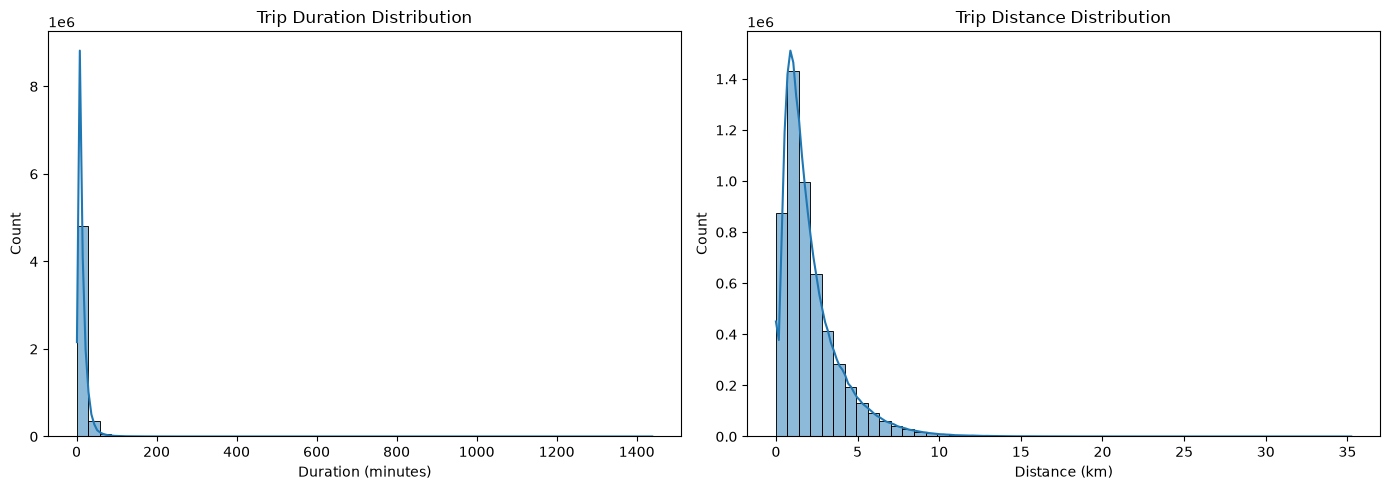

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned data
df = pd.read_csv(
    r"C:\City Bike\data\processed\citibike_final_cleaned.csv"
)

# Summary statistics
print(df[["trip_duration_min", "trip_distance_km"]].describe())

# Histograms
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["trip_duration_min"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Trip Duration Distribution")
axes[0].set_xlabel("Duration (minutes)")

sns.histplot(df["trip_distance_km"], bins=50, kde=True, ax=axes[1])
axes[1].set_title("Trip Distance Distribution")
axes[1].set_xlabel("Distance (km)")

plt.tight_layout()
plt.show()

c:\Users\Chinmaya Harekrishna\anaconda3\envs\myenv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


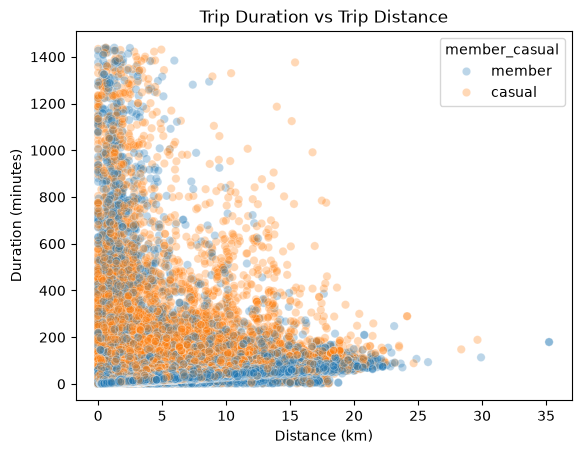

In [4]:
sns.scatterplot(
    data=df,
    x="trip_distance_km",
    y="trip_duration_min",
    hue="member_casual",
    alpha=0.3
)

plt.title("Trip Duration vs Trip Distance")
plt.xlabel("Distance (km)")
plt.ylabel("Duration (minutes)")
plt.show()

In [5]:
df.groupby("member_casual")[
    ["trip_duration_min", "trip_distance_km"]
].mean()

,trip_duration_min,trip_distance_km
member_casual,,
casual,20.009702,2.292202
member,12.169858,2.105280


In [6]:
# Create hour from started_at
df["started_at"] = pd.to_datetime(df["started_at"], errors="coerce")
df["hour"] = df["started_at"].dt.hour

# Count trips per hour
trips_by_hour = df["hour"].value_counts().sort_index()

trips_by_hour

hour
0      89255
1      57417
2      36153
3      23423
4      20083
5      36165
6      94111
7     173485
8     294594
9     271331
10    237060
11    259575
12    292949
13    307517
14    315661
15    330646
16    373975
17    470746
18    433005
19    359170
20    267005
21    205881
22    168956
23    126810
Name: count, dtype: int64

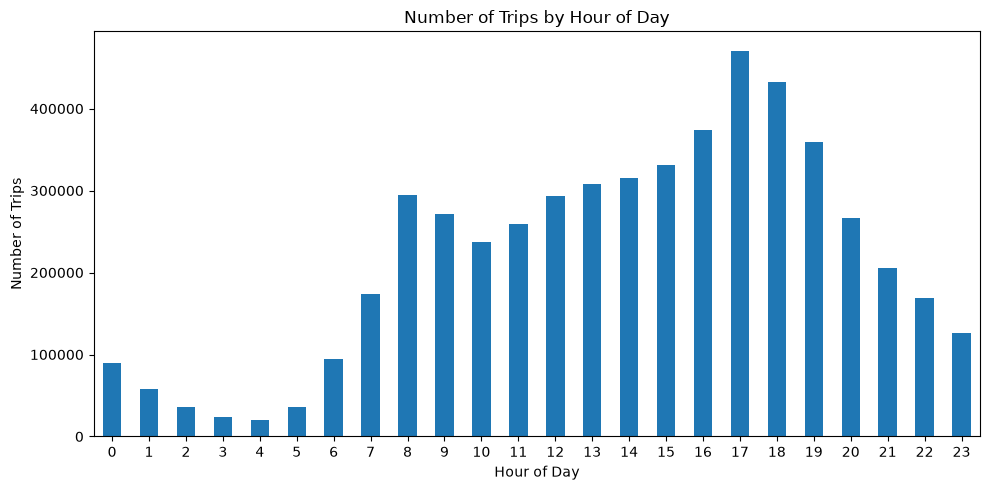

In [7]:
import matplotlib.pyplot as plt

trips_by_hour.plot(kind="bar", figsize=(10, 5))

plt.title("Number of Trips by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [8]:
# Create day of week
df["started_at"] = pd.to_datetime(df["started_at"], errors="coerce")
df["day_of_week"] = df["started_at"].dt.day_name()

# Count trips by day
trips_by_day = df["day_of_week"].value_counts().reindex([
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
])

trips_by_day

day_of_week
Monday       747350
Tuesday      717836
Wednesday    728694
Thursday     605879
Friday       695962
Saturday     973274
Sunday       775978
Name: count, dtype: int64

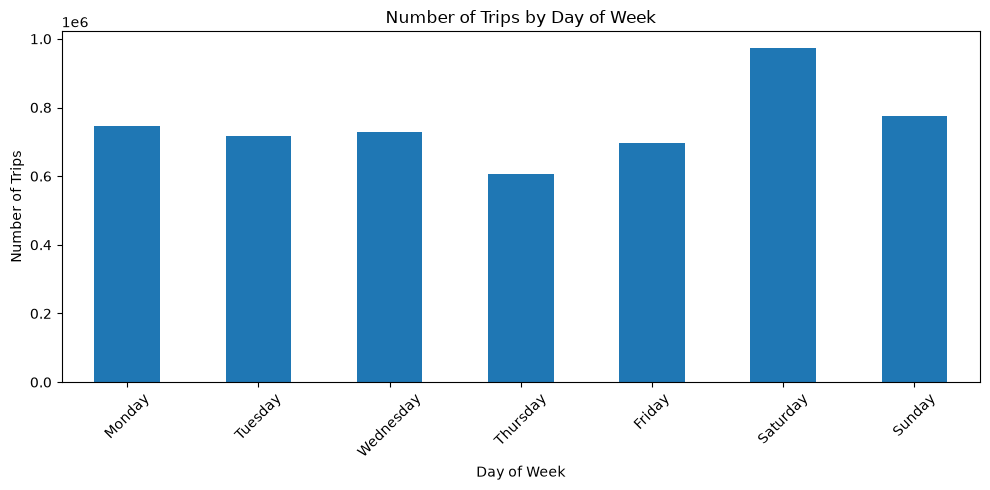

In [9]:
trips_by_day.plot(kind="bar", figsize=(10, 5))

plt.title("Number of Trips by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Trips")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
# Count trips by rider type
member_counts = df["member_casual"].value_counts()

member_counts

member_casual
member    4117846
casual    1127127
Name: count, dtype: int64

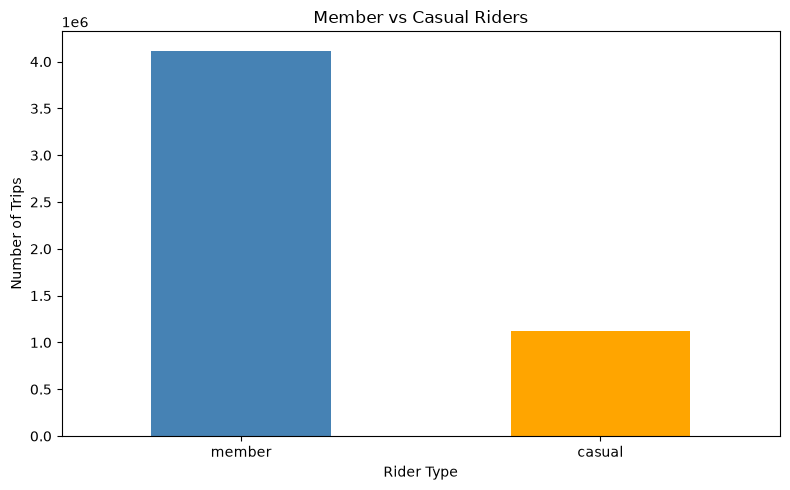

In [11]:
member_counts.plot(
    kind="bar",
    figsize=(8, 5),
    color=["steelblue", "orange"]
)

plt.title("Member vs Casual Riders")
plt.xlabel("Rider Type")
plt.ylabel("Number of Trips")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [13]:
comparison = df.groupby("member_casual")[
    ["trip_duration_min", "trip_distance_km"]
].mean()

comparison

,trip_duration_min,trip_distance_km
member_casual,,
casual,20.009702,2.292202
member,12.169858,2.105280


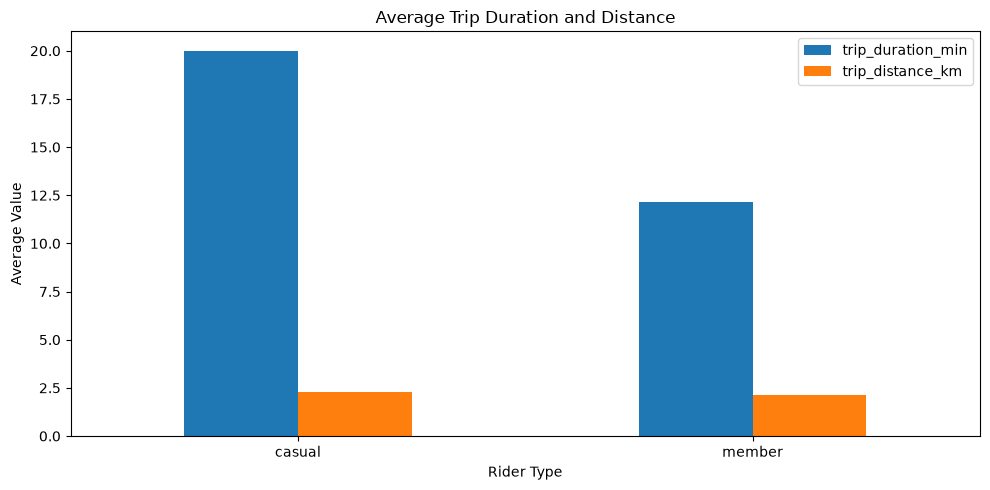

In [14]:
comparison.plot(kind="bar", figsize=(10, 5))

plt.title("Average Trip Duration and Distance")
plt.xlabel("Rider Type")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [20]:
duration_distance = df[
    ["trip_duration_min", "trip_distance_km"]
].describe()

duration_distance


,trip_duration_min,trip_distance_km
count,5.244973e+06,5.244973e+06
mean,1.385461e+01,2.145449e+00
std,1.977956e+01,1.837261e+00
min,1.000083e+00,0.000000e+00
25%,5.681367e+00,9.064423e-01
50%,9.784467e+00,1.603310e+00
75%,1.697128e+01,2.818134e+00
max,1.438873e+03,3.523348e+01


C:\Users\Chinmaya Harekrishna\AppData\Local\Temp\ipykernel_32712\1026463530.py:12: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\Chinmaya Harekrishna\anaconda3\envs\myenv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


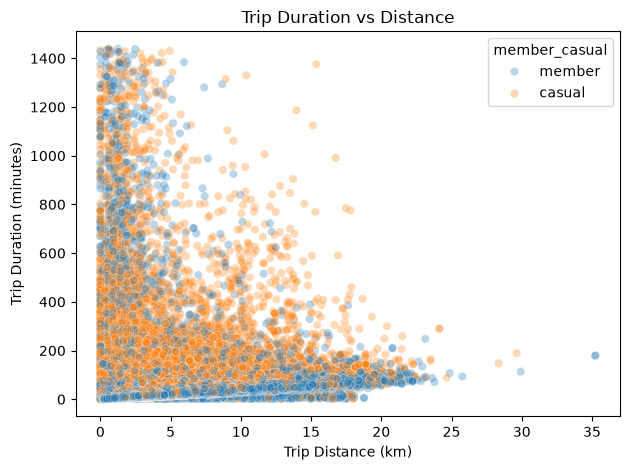

In [21]:
sns.scatterplot(
    data=df,
    x="trip_distance_km",
    y="trip_duration_min",
    hue="member_casual",
    alpha=0.3
)

plt.title("Trip Duration vs Distance")
plt.xlabel("Trip Distance (km)")
plt.ylabel("Trip Duration (minutes)")
plt.tight_layout()
plt.show()

In [22]:
# Create weekend/weekday categories
df["started_at"] = pd.to_datetime(df["started_at"], errors="coerce")
df["day_type"] = df["started_at"].dt.dayofweek.map(
    lambda day: "Weekend" if day >= 5 else "Weekday"
)

# Compare trip count, duration, and distance
weekend_weekday = df.groupby("day_type").agg(
    trip_count=("ride_id", "count"),
    average_duration=("trip_duration_min", "mean"),
    average_distance=("trip_distance_km", "mean")
)

weekend_weekday

,trip_count,average_duration,average_distance
day_type,,,
Weekday,3495721,12.83547,2.08483
Weekend,1749252,15.89128,2.26659


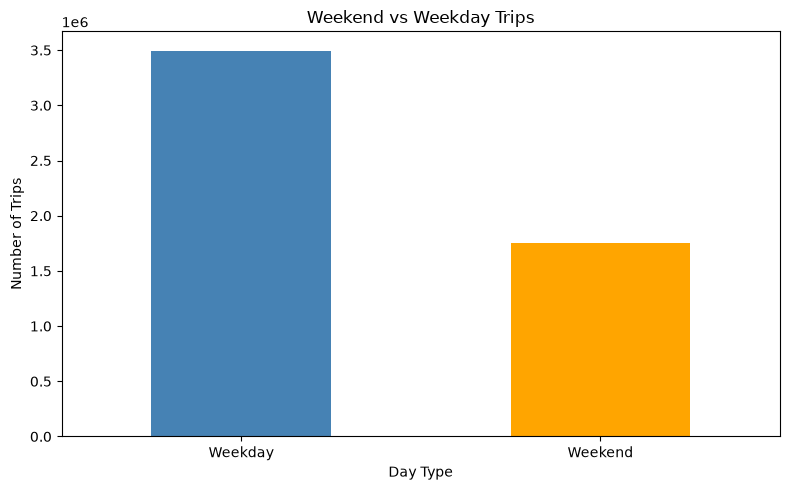

In [23]:
weekend_weekday["trip_count"].plot(
    kind="bar",
    figsize=(8, 5),
    color=["steelblue", "orange"]
)

plt.title("Weekend vs Weekday Trips")
plt.xlabel("Day Type")
plt.ylabel("Number of Trips")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()